# Tech Challenge — Fase 3

## Assistente Médico com LLM, LangChain e LangGraph

Este notebook documenta o desenvolvimento do Tech Challenge da Fase 3.

O objetivo do projeto é construir um assistente médico capaz de utilizar um modelo de linguagem especializado, consultar informações de pacientes e utilizar conteúdos médicos como contexto para responder perguntas clínicas.

O projeto será desenvolvido de forma incremental, documentando as decisões tomadas em cada etapa.

De acordo com os requisitos do Tech Challenge, o projeto deverá contemplar:

- preparação e curadoria de dados médicos;
- utilização de dados anonimizados ou sintéticos;
- especialização de um modelo de linguagem;
- integração do modelo com LangChain;
- consulta a informações estruturadas de pacientes;
- utilização de contexto clínico nas respostas;
- orquestração do fluxo utilizando LangGraph;
- mecanismos de segurança e validação;
- indicação das fontes utilizadas;
- registro de logs para auditoria.

Para os dados científicos utilizaremos o **PubMedQA**, um conjunto de perguntas e respostas baseadas em artigos biomédicos.

Além disso, criaremos dados hospitalares sintéticos para representar informações internas de um hospital, como:

- protocolos médicos;
- perguntas frequentes de profissionais;
- modelos de relatórios e procedimentos;
- dados clínicos fictícios de pacientes.

A implementação será mantida simples e modular, utilizando somente os componentes necessários para atender aos requisitos do desafio.

## 1. Arquitetura proposta

Antes de implementar o código, definimos uma arquitetura simples para o assistente.

O fluxo geral será:

1. Preparar os dados médicos.
2. Especializar um modelo de linguagem utilizando esses dados.
3. Criar uma pequena base estruturada contendo pacientes fictícios.
4. Criar uma base de conhecimento contendo protocolos e documentos hospitalares sintéticos.
5. Utilizar LangChain para integrar o modelo aos diferentes componentes.
6. Utilizar LangGraph para controlar o fluxo da aplicação.
7. Aplicar uma etapa de validação de segurança antes de entregar a resposta final.
8. Registrar informações importantes da execução para auditoria.

Fluxo simplificado:

Pergunta do usuário  
↓  
Identificação do paciente  
↓  
Consulta dos dados clínicos  
↓  
Busca de contexto médico  
↓  
Modelo de linguagem  
↓  
Validação de segurança  
↓  
Resposta + fontes + log

## 2. Preparação do ambiente

Nesta etapa serão instaladas apenas as bibliotecas necessárias para o desenvolvimento do projeto.

Ao longo do notebook adicionaremos novas dependências somente quando forem realmente necessárias.

Inicialmente utilizaremos bibliotecas para:

- manipulação dos dados;
- integração com modelos de linguagem;
- construção das chains;
- construção do fluxo com LangGraph;
- recuperação de documentos.

In [1]:
!pip install -q langchain langgraph faiss-cpu datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 58.0 MB/s eta 0:00:00


## 4. Carregamento do dataset PubMedQA

Nesta etapa iremos carregar o PubMedQA, que será utilizado como fonte de conhecimento médico científico.

Antes de preparar os dados para qualquer etapa de especialização do modelo, é importante analisar a estrutura original do dataset.

Vamos verificar:

- quantidade de registros;
- formato dos dados;
- campos disponíveis em cada exemplo;
- distribuição das respostas.

In [3]:
!git clone -q https://github.com/pubmedqa/pubmedqa.git

In [4]:
import json

caminho_pubmedqa = "pubmedqa/data/ori_pqal.json"

with open(caminho_pubmedqa, "r", encoding="utf-8") as arquivo:
    pubmedqa = json.load(arquivo)

print("Tipo do dataset:", type(pubmedqa))
print("Quantidade de registros:", len(pubmedqa))

Tipo do dataset: <class 'dict'>
Quantidade de registros: 1000


In [5]:
primeiro_id = next(iter(pubmedqa))

print("Identificador:", primeiro_id)
print()

print(
    json.dumps(
        pubmedqa[primeiro_id],
        indent=2,
        ensure_ascii=False
    )
)

Identificador: 21645374

{
  "QUESTION": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "CONTEXTS": [
    "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.",
    "The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD),

### 4.2 Distribuição das respostas

O PubMedQA utiliza três possíveis decisões finais:

- `yes`
- `no`
- `maybe`

Antes de dividir ou transformar o dataset, iremos verificar quantos exemplos existem em cada classe.

Essa análise é importante para entender se existe algum desbalanceamento entre as respostas.

In [6]:
from collections import Counter

distribuicao_respostas = Counter(
    registro["final_decision"]
    for registro in pubmedqa.values()
)

print("Distribuição das respostas:")

for resposta, quantidade in distribuicao_respostas.items():
    print(f"{resposta}: {quantidade}")

Distribuição das respostas:
yes: 552
no: 338
maybe: 110


### 4.3 Análise dos campos do PubMedQA

Após inspecionar um registro original, identificamos os seguintes campos:

- `QUESTION`: pergunta que deverá ser respondida.
- `CONTEXTS`: trechos de literatura científica que fornecem o contexto necessário para a resposta.
- `LABELS`: classificação dos trechos do contexto, como `BACKGROUND` e `RESULTS`.
- `MESHES`: termos médicos/científicos associados ao artigo.
- `YEAR`: ano da publicação.
- `reasoning_required_pred`: predição auxiliar presente no dataset.
- `reasoning_free_pred`: outra predição auxiliar presente no dataset.
- `final_decision`: resposta final classificada como `yes`, `no` ou `maybe`.
- `LONG_ANSWER`: explicação textual detalhada da resposta.

Para este projeto, nem todos os campos são necessários.

Utilizaremos principalmente:

- `QUESTION`
- `CONTEXTS`
- `final_decision`
- `LONG_ANSWER`

Esses campos formam uma estrutura adequada para especialização do modelo:

**Contexto científico + Pergunta → Resposta + Explicação**

Os demais campos serão preservados no dataset original, mas não serão utilizados inicialmente na preparação dos exemplos.

### 4.4 Curadoria inicial dos dados

Antes de utilizar os exemplos, realizaremos uma etapa simples de curadoria.

Serão verificados:

- registros sem pergunta;
- registros sem contexto;
- registros sem resposta final;
- registros sem explicação.

Também iremos transformar a lista presente em `CONTEXTS` em um único texto contínuo.

Nesta etapa não realizaremos tradução do conteúdo. Os textos científicos serão mantidos em inglês, preservando o conteúdo original do PubMedQA.

O identificador de cada registro também será mantido para permitir rastrear a origem do exemplo posteriormente.

In [7]:
campos_obrigatorios = [
    "QUESTION",
    "CONTEXTS",
    "final_decision",
    "LONG_ANSWER"
]

registros_incompletos = []

for identificador, registro in pubmedqa.items():

    for campo in campos_obrigatorios:
        if not registro.get(campo):
            registros_incompletos.append({
                "id": identificador,
                "campo": campo
            })

print("Registros com campos obrigatórios ausentes:")
print(len(registros_incompletos))

if registros_incompletos:
    print(registros_incompletos[:10])

Registros com campos obrigatórios ausentes:
0


### 4.5 Resultado da verificação

A análise não identificou registros com ausência nos campos selecionados.

Portanto, os 1.000 exemplos do conjunto PQA-L podem ser mantidos nesta etapa.

A seguir, criaremos uma representação simplificada dos dados contendo somente as informações necessárias para o projeto, sem alterar o dataset original.

In [18]:
dataset_pubmedqa = []

for identificador, registro in pubmedqa.items():

    contexto = "\n\n".join(registro["CONTEXTS"])

    exemplo = {
        "id": identificador,
        "question": registro["QUESTION"],
        "context": contexto,
        "answer": registro["final_decision"],
        "explanation": registro["LONG_ANSWER"]
    }

    dataset_pubmedqa.append(exemplo)

print("Quantidade de exemplos preparados:", len(dataset_pubmedqa))

Quantidade de exemplos preparados: 1000


In [9]:
print(json.dumps(
    dataset_pubmedqa[0],
    indent=2,
    ensure_ascii=False
))

{
  "id": "21645374",
  "question": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "context": "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.\n\nThe following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early 

## 5. Separação dos dados em treino e teste

Para avaliar posteriormente se a especialização do modelo realmente trouxe resultados, não devemos utilizar todos os exemplos durante o treinamento.

O dataset será dividido em:

- **80% para treinamento:** exemplos que poderão ser utilizados na especialização do modelo.
- **20% para teste:** exemplos reservados para avaliação posterior.

Como o PubMedQA possui três classes (`yes`, `no` e `maybe`) com quantidades diferentes de exemplos, utilizaremos uma divisão estratificada.

A estratificação mantém aproximadamente a mesma proporção das três classes nos conjuntos de treino e teste.

Também utilizaremos uma semente fixa (`random_state=42`) para tornar a divisão reproduzível.

In [10]:
from sklearn.model_selection import train_test_split

dataset_treino, dataset_teste = train_test_split(
    dataset_pubmedqa,
    test_size=0.20,
    random_state=42,
    stratify=[
        exemplo["answer"]
        for exemplo in dataset_pubmedqa
    ]
)

print("Total:", len(dataset_pubmedqa))
print("Treino:", len(dataset_treino))
print("Teste:", len(dataset_teste))

Total: 1000
Treino: 800
Teste: 200


### 5.1 Verificação da distribuição das classes

Após a divisão, verificaremos a quantidade de respostas `yes`, `no` e `maybe` nos conjuntos de treino e teste.

Essa verificação permite confirmar que a divisão estratificada preservou a distribuição original das classes.

In [19]:
from collections import Counter

distribuicao_treino = Counter(
    exemplo["answer"]
    for exemplo in dataset_treino
)

distribuicao_teste = Counter(
    exemplo["answer"]
    for exemplo in dataset_teste
)

print("Treino:")
for classe, quantidade in distribuicao_treino.items():
    print(f"{classe}: {quantidade}")

print("\nTeste:")
for classe, quantidade in distribuicao_teste.items():
    print(f"{classe}: {quantidade}")

Treino:
no: 270
yes: 442
maybe: 88

Teste:
yes: 110
no: 68
maybe: 22


### 5.2 Resultado da divisão

O PubMedQA foi dividido em:

- **800 exemplos de treinamento**
- **200 exemplos de teste**

A distribuição das classes foi preservada por meio da divisão estratificada.

O conjunto de teste será mantido separado e não deverá ser utilizado durante a especialização do modelo. Ele será utilizado posteriormente para comparar o comportamento do modelo antes e depois da especialização.

Até este ponto realizamos apenas a preparação e curadoria dos dados. Ainda não definimos o formato específico de entrada do modelo, pois essa estrutura dependerá da estratégia de especialização escolhida na próxima etapa.

## 6. Preparação dos dados para Fine-tuning

Até este momento, os exemplos do PubMedQA foram preparados e separados entre treino e teste.

vamos representar cada exemplo utilizando três campos principais:

- **instruction**: descreve a tarefa que o modelo deverá executar;
- **input**: contém as informações fornecidas ao modelo;
- **output**: representa a resposta esperada.

No nosso caso:

- a `instruction` será fixa;
- o `input` conterá o contexto científico e a pergunta;
- o `output` conterá a decisão final e sua justificativa.

Essa estrutura permitirá posteriormente converter os exemplos para o formato textual utilizado durante o fine-tuning.

### 6.1 Estrutura dos exemplos

A estrutura adotada será:

**Instruction**

Define a tarefa:

> Responder à pergunta utilizando o contexto científico fornecido.

**Input**

Será composto por:

- contexto científico;
- pergunta.

**Output**

Será composto por:

- resposta final (`yes`, `no` ou `maybe`);
- justificativa presente no PubMedQA.

Dessa forma, mantemos os dados originais relevantes e utilizamos uma organização semelhante à utilizada no material prático da disciplina.

In [21]:
def preparar_exemplo(exemplo):

    return {
        "id": exemplo["id"],

        "instruction": (
            "Responda à pergunta utilizando apenas "
            "o contexto científico fornecido."
        ),

        "input": (
            f"Contexto:\n{exemplo['context']}\n\n"
            f"Pergunta:\n{exemplo['question']}"
        ),

        "output": (
            f"Resposta: {exemplo['answer']}\n\n"
            f"Justificativa: {exemplo['explanation']}"
        )
    }

### 6.2 Preparação dos conjuntos de treino e teste

Aplicaremos a mesma transformação aos conjuntos de treino e teste.

O conjunto de teste continuará separado e não será utilizado para atualização dos parâmetros do modelo durante o fine-tuning.

In [22]:
dataset_treino_preparado = [
    preparar_exemplo(exemplo)
    for exemplo in dataset_treino
]

dataset_teste_preparado = [
    preparar_exemplo(exemplo)
    for exemplo in dataset_teste
]

print("Treino:", len(dataset_treino_preparado))
print("Teste:", len(dataset_teste_preparado))

Treino: 800
Teste: 200


### 6.3 Verificação de um exemplo preparado

Antes de converter os dados para o formato utilizado pelo modelo, iremos inspecionar um exemplo.

Essa etapa permite verificar se a instrução, a entrada e a saída esperada foram organizadas corretamente.

In [23]:
import json

print(
    json.dumps(
        dataset_treino_preparado[0],
        indent=2,
        ensure_ascii=False
    )
)

{
  "id": "9347843",
  "instruction": "Responda à pergunta utilizando apenas o contexto científico fornecido.",
  "input": "Contexto:\nBecause of the inflammatory nature of Crohn's disease, ileocolic resections are often difficult to perform, especially if an abscess, phlegmon, or recurrent disease at a previous ileocolic anastomosis is present. Our goal was to determine whether the above factors are contraindications to a successful laparoscopic-assisted ileocolic resection.\n\nBetween 1992 and 1996, 46 laparoscopic-assisted ileocolic resections were attempted. Fourteen patients had an abscess or phlegmon treated with bowel rest before operation (group I), 10 patients had recurrent Crohn's disease at the previous ileocolic anastomosis (group II), and 22 patients had no previous operation and no phlegmon or abscess associated with their disease (group III). These groups were compared with each other and with 70 consecutive open ileocolic resections for Crohn's disease during the same t

### 6.4 Formatação textual para treinamento

Os campos `instruction`, `input` e `output` organizam semanticamente cada exemplo.

Entretanto, o modelo receberá uma sequência textual durante o treinamento.

Por isso, criaremos um template que concatena esses campos de maneira padronizada.

O mesmo formato deverá ser mantido posteriormente quando utilizarmos o modelo especializado para realizar inferências.

In [24]:
template_prompt = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

In [25]:
def formatar_para_treinamento(exemplo):

    texto = template_prompt.format(
        exemplo["instruction"],
        exemplo["input"],
        exemplo["output"]
    )

    return {
        **exemplo,
        "text": texto
    }


dataset_treino_formatado = [
    formatar_para_treinamento(exemplo)
    for exemplo in dataset_treino_preparado
]

dataset_teste_formatado = [
    formatar_para_treinamento(exemplo)
    for exemplo in dataset_teste_preparado
]

In [26]:
print(dataset_treino_formatado[0]["text"])

Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
Responda à pergunta utilizando apenas o contexto científico fornecido.

### Input:
Contexto:
Because of the inflammatory nature of Crohn's disease, ileocolic resections are often difficult to perform, especially if an abscess, phlegmon, or recurrent disease at a previous ileocolic anastomosis is present. Our goal was to determine whether the above factors are contraindications to a successful laparoscopic-assisted ileocolic resection.

Between 1992 and 1996, 46 laparoscopic-assisted ileocolic resections were attempted. Fourteen patients had an abscess or phlegmon treated with bowel rest before operation (group I), 10 patients had recurrent Crohn's disease at the previous ileocolic anastomosis (group II), and 22 patients had no previous operation and no phlegmon or abscess associated with their disease (group III)

### 6.5 Corpus hospitalar para o fine-tuning

O requisito 1 do desafio determina que o fine-tuning utilize os **dados próprios do hospital**:

- protocolos médicos do hospital;
- exemplos de perguntas frequentes feitas por médicos;
- modelos de laudos, receitas e procedimentos internos.

O PubMedQA fornece o raciocínio clínico sobre literatura biomédica, mas não contém nenhum desses três conjuntos. Por isso, construiremos agora a base hospitalar e, a partir dela, um **corpus de instruções** que será somado ao conjunto de treinamento.

Para evitar a utilização de dados pessoais ou informações médicas reais, todos os registros são **sintéticos** — a anonimização é garantida por construção.

Esta mesma base será reaproveitada adiante como fonte de conhecimento do RAG (seção 12) e como prontuário consultado pelo assistente (seção 14).

#### 6.5.1 Protocolos médicos internos

In [27]:
protocolos = [
    {
        "id": "PROTOCOLO_001",
        "titulo": "Atendimento inicial de hipertensão arterial",
        "conteudo": """
Pacientes com pressão arterial elevada devem passar por avaliação
clínica e confirmação das medidas de pressão arterial.

Devem ser considerados histórico clínico, medicamentos em uso,
fatores de risco cardiovascular e presença de sintomas associados.

Casos com pressão arterial muito elevada acompanhada de sintomas
como dor no peito, falta de ar, alteração neurológica ou perda de
consciência devem receber avaliação médica imediata.

Qualquer decisão terapêutica ou alteração de medicamento deve ser
validada por um profissional médico.
"""
    },

    {
        "id": "PROTOCOLO_002",
        "titulo": "Atendimento inicial de pacientes com febre",
        "conteudo": """
Pacientes com febre devem ser avaliados considerando duração dos
sintomas, temperatura registrada e presença de outros sinais clínicos.

Devem ser observados sintomas associados como dificuldade respiratória,
alteração do estado de consciência, dor intensa e sinais de desidratação.

A presença de sinais de gravidade deve resultar em avaliação médica
prioritária.

O assistente não deve realizar diagnóstico definitivo nem prescrever
medicamentos.
"""
    },

    {
        "id": "PROTOCOLO_003",
        "titulo": "Atendimento inicial de sintomas respiratórios",
        "conteudo": """
Pacientes com sintomas respiratórios devem ser avaliados considerando
tosse, duração dos sintomas, presença de febre, falta de ar e outros
sinais clínicos.

Sinais como dificuldade respiratória importante, alteração do nível
de consciência ou piora clínica significativa devem resultar em
avaliação médica imediata.

As informações fornecidas pelo assistente possuem caráter de apoio
e não substituem avaliação médica.
"""
    }
]

print("Protocolos cadastrados:", len(protocolos))

Protocolos cadastrados: 3


#### 6.5.2 Perguntas frequentes

As perguntas frequentes representam dúvidas recorrentes dos médicos e definem os **limites de atuação** do assistente.

In [28]:
faqs = [
    {
        "id": "FAQ_001",
        "pergunta": "O assistente pode prescrever medicamentos?",
        "resposta": """
Não. O assistente pode fornecer informações de apoio, mas prescrições
e alterações de medicamentos devem ser realizadas ou validadas por
um profissional médico.
"""
    },

    {
        "id": "FAQ_002",
        "pergunta": "O assistente pode realizar um diagnóstico?",
        "resposta": """
O assistente pode auxiliar na análise das informações disponíveis,
mas não deve fornecer um diagnóstico definitivo sem validação médica.
"""
    },

    {
        "id": "FAQ_003",
        "pergunta": "Quando um paciente deve receber avaliação médica imediata?",
        "resposta": """
Situações com sinais de gravidade, como dificuldade respiratória
importante, perda de consciência, alterações neurológicas ou piora
clínica significativa, devem receber avaliação médica imediata.
"""
    }
]

print("FAQs cadastradas:", len(faqs))

FAQs cadastradas: 3


#### 6.5.3 Modelos de documentos internos

Cobrem os três tipos citados no desafio: **laudos** (relatório médico e laudo de exame), **receitas** (receituário) e **procedimentos** (registro de procedimento).

Os modelos contêm apenas a estrutura de campos — nenhum dado de paciente é preenchido.

In [29]:
modelos_documentos = [
    {
        "id": "MODELO_001",
        "tipo": "Relatório médico",
        "conteudo": """
Relatório Médico

Paciente:
Data:
Motivo do atendimento:
Histórico clínico:
Sintomas apresentados:
Avaliação:
Conduta:
Profissional responsável:
"""
    },

    {
        "id": "MODELO_002",
        "tipo": "Registro de procedimento",
        "conteudo": """
Registro de Procedimento

Paciente:
Data:
Procedimento realizado:
Indicação:
Descrição:
Intercorrências:
Profissional responsável:
"""
    },

    {
        "id": "MODELO_003",
        "tipo": "Laudo de exame",
        "conteudo": """
Laudo de Exame

Paciente:
Data:
Exame realizado:
Indicação clínica:
Técnica utilizada:
Descrição dos achados:
Conclusão:
Profissional responsável:
"""
    },

    {
        "id": "MODELO_004",
        "tipo": "Receituário",
        "conteudo": """
Receituário

Paciente:
Data:
Prescrição:
Orientações de uso:
Observações:
Profissional responsável (nome e registro):
Assinatura:

Documento válido somente quando preenchido, assinado e validado
por profissional médico habilitado. O assistente não preenche
prescrições.
"""
    }
]

print("Modelos cadastrados:", len(modelos_documentos))

Modelos cadastrados: 4


#### 6.5.4 Registros sintéticos de pacientes

Os registros fictícios permitem contextualizar as respostas com dados estruturados, simulando um prontuário.

In [30]:
pacientes = [
    {
        "id": "P001",
        "idade": 58,
        "sexo": "Masculino",
        "historico": [
            "Hipertensão arterial"
        ],
        "medicamentos": [
            "Losartana"
        ],
        "alergias": [],
        "observacoes": "Paciente em acompanhamento clínico."
    },

    {
        "id": "P002",
        "idade": 42,
        "sexo": "Feminino",
        "historico": [
            "Asma"
        ],
        "medicamentos": [
            "Salbutamol"
        ],
        "alergias": [
            "Dipirona"
        ],
        "observacoes": "Histórico de episódios de sintomas respiratórios."
    },

    {
        "id": "P003",
        "idade": 67,
        "sexo": "Masculino",
        "historico": [
            "Diabetes mellitus tipo 2",
            "Hipertensão arterial"
        ],
        "medicamentos": [
            "Metformina",
            "Losartana"
        ],
        "alergias": [],
        "observacoes": "Paciente em acompanhamento periódico."
    }
]

print("Pacientes cadastrados:", len(pacientes))

Pacientes cadastrados: 3


#### 6.5.5 Consulta aos registros estruturados

As funções abaixo consultam e formatam o prontuário. Elas são definidas aqui porque o corpus de fine-tuning precisa reproduzir exatamente o mesmo formato de contexto que o assistente receberá em produção.

In [31]:
def buscar_paciente(id_paciente):
    for paciente in pacientes:
        if paciente["id"] == id_paciente:
            return paciente

    return None

In [32]:
def formatar_paciente(paciente):
    if paciente is None:
        return "Paciente não encontrado."

    historico = ", ".join(paciente["historico"]) or "Não informado"
    medicamentos = ", ".join(paciente["medicamentos"]) or "Não informado"
    alergias = ", ".join(paciente["alergias"]) or "Nenhuma informada"

    return f"""
ID: {paciente['id']}
Idade: {paciente['idade']}
Sexo: {paciente['sexo']}
Histórico clínico: {historico}
Medicamentos em uso: {medicamentos}
Alergias: {alergias}
Observações: {paciente['observacoes']}
""".strip()

#### 6.5.6 Formato dos exemplos hospitalares

Um ponto importante: os exemplos hospitalares são construídos no **mesmo formato que o assistente recebe em tempo de execução** — instrução, dados do paciente, contexto recuperado e pergunta.

Isso evita divergência entre treino e inferência: o modelo é treinado exatamente no formato em que será consultado pelo fluxo LangGraph.

A instrução dos exemplos hospitalares é **diferente** da instrução usada no PubMedQA. Assim o modelo condiciona o formato da saída à tarefa solicitada, e um corpus não degrada o outro.

In [33]:
INSTRUCAO_ASSISTENTE = """Analise as informações do paciente utilizando apenas o contexto fornecido.

Forneça uma resposta objetiva de apoio clínico.

Não realize diagnóstico definitivo.
Não prescreva medicamentos.
Não altere tratamentos.

Qualquer decisão clínica deve ser validada por um profissional de saúde.

Ao final, indique a fonte utilizada."""


INSTRUCAO_DOCUMENTOS = """Apresente a estrutura do modelo de documento interno do hospital.

Mantenha os campos padronizados, sem preencher dados de pacientes.

Ao final, indique a fonte utilizada."""


TEMPLATE_ENTRADA_ASSISTENTE = """DADOS DO PACIENTE:
{paciente}

CONTEXTO:
{contexto}

PERGUNTA:
{pergunta}"""

SEM_PACIENTE = "Não informado."

In [34]:
def formatar_contexto(itens):
    """Formata os trechos no mesmo padrão usado pelo retriever (Fonte/Conteúdo)."""
    return "\n\n".join(
        f"Fonte: {fonte}\nConteúdo: {conteudo}"
        for fonte, conteudo in itens
    )


def montar_exemplo_hospitalar(identificador, instrucao, contexto_paciente,
                              contexto_documentos, pergunta, resposta, fonte):
    """Monta um exemplo no formato instruction/input/output."""
    entrada = TEMPLATE_ENTRADA_ASSISTENTE.format(
        paciente=contexto_paciente,
        contexto=contexto_documentos,
        pergunta=pergunta
    )

    return {
        "id": identificador,
        "instruction": instrucao,
        "input": entrada,
        "output": f"{resposta}\n\nFonte utilizada: {fonte}",
        "origem": "hospital"
    }


indice_protocolos = {p["id"]: p for p in protocolos}
indice_faqs = {f["id"]: f for f in faqs}

#### 6.5.7 Exemplos clínicos curados a partir dos protocolos

As respostas são **curadas manualmente** a partir do texto dos protocolos: nenhuma conduta que extrapole o protocolo é introduzida, e todas reforçam os limites de atuação.

O campo `distrator` reproduz o comportamento real do retriever, que recupera `k=2` trechos. Assim o modelo aprende a se apoiar no protocolo pertinente e a citar apenas a fonte efetivamente utilizada.

In [35]:
EXEMPLOS_CLINICOS = [
    {
        "id": "HOSP_CLIN_001",
        "protocolo": "PROTOCOLO_001",
        "distrator": "PROTOCOLO_002",
        "paciente": "P001",
        "pergunta": (
            "Quais informações são relevantes para o acompanhamento "
            "deste paciente com hipertensão?"
        ),
        "resposta": """O protocolo interno orienta iniciar por avaliação clínica e confirmação das medidas de pressão arterial.

Devem ser considerados o histórico clínico de hipertensão arterial, os medicamentos em uso registrados no prontuário, os fatores de risco cardiovascular e a presença de sintomas associados.

Sinais como dor no peito, falta de ar, alteração neurológica ou perda de consciência indicam necessidade de avaliação médica imediata.

Qualquer decisão terapêutica ou alteração de medicamento deve ser validada por um profissional médico."""
    },

    {
        "id": "HOSP_CLIN_002",
        "protocolo": "PROTOCOLO_001",
        "distrator": None,
        "paciente": "P001",
        "pergunta": "O paciente relata dor no peito e falta de ar desde ontem. Como proceder?",
        "resposta": """Os sintomas relatados constam no protocolo como sinais que exigem avaliação médica imediata em pacientes com pressão arterial elevada.

A orientação é encaminhar o paciente para avaliação médica imediata, sem aguardar novas medições.

Não é possível estabelecer diagnóstico definitivo nem indicar tratamento por este canal: a conduta deve ser definida por um profissional médico."""
    },

    {
        "id": "HOSP_CLIN_003",
        "protocolo": "PROTOCOLO_001",
        "distrator": "PROTOCOLO_003",
        "paciente": "P003",
        "pergunta": "Quais informações devem ser consideradas no acompanhamento deste paciente?",
        "resposta": """O prontuário registra histórico de hipertensão arterial e diabetes mellitus tipo 2, com medicamentos em uso já cadastrados.

Conforme o protocolo interno, o acompanhamento deve incluir a confirmação das medidas de pressão arterial e a avaliação clínica, considerando histórico, medicamentos em uso, fatores de risco cardiovascular e sintomas associados.

A presença de sintomas de alarme indica avaliação médica imediata.

Alterações de tratamento devem ser validadas por um profissional médico."""
    },

    {
        "id": "HOSP_CLIN_004",
        "protocolo": "PROTOCOLO_002",
        "distrator": "PROTOCOLO_001",
        "paciente": "P003",
        "pergunta": "O paciente apresenta febre há três dias. Quais informações devem ser avaliadas?",
        "resposta": """O protocolo de atendimento inicial de pacientes com febre orienta avaliar a duração dos sintomas, a temperatura registrada e a presença de outros sinais clínicos.

Devem ser observados sintomas associados como dificuldade respiratória, alteração do estado de consciência, dor intensa e sinais de desidratação.

A presença de sinais de gravidade indica avaliação médica prioritária.

Não cabe a este assistente estabelecer diagnóstico definitivo ou prescrever medicamentos."""
    },

    {
        "id": "HOSP_CLIN_005",
        "protocolo": "PROTOCOLO_002",
        "distrator": None,
        "paciente": "P002",
        "pergunta": "Posso indicar um antitérmico para esta paciente?",
        "resposta": """Não é possível indicar medicamentos por este canal.

A atuação do assistente se limita ao apoio informativo: conforme o protocolo, a avaliação considera a duração dos sintomas, a temperatura registrada e os sinais clínicos associados.

Registre-se que o prontuário da paciente informa alergia a Dipirona, informação relevante para a avaliação médica.

Qualquer prescrição deve ser realizada e validada por um profissional médico."""
    },

    {
        "id": "HOSP_CLIN_006",
        "protocolo": "PROTOCOLO_003",
        "distrator": "PROTOCOLO_002",
        "paciente": "P002",
        "pergunta": (
            "Quais informações são relevantes para uma paciente "
            "com histórico de sintomas respiratórios?"
        ),
        "resposta": """Conforme o protocolo interno, a avaliação de sintomas respiratórios deve considerar tosse, duração dos sintomas, presença de febre, falta de ar e demais sinais clínicos.

O prontuário registra histórico de asma, medicação em uso e alergia a Dipirona.

Dificuldade respiratória importante, alteração do nível de consciência ou piora clínica significativa indicam avaliação médica imediata.

As informações têm caráter de apoio e não substituem a avaliação médica."""
    },

    {
        "id": "HOSP_CLIN_007",
        "protocolo": "PROTOCOLO_003",
        "distrator": None,
        "paciente": "P002",
        "pergunta": "A paciente apresenta piora importante da falta de ar. Qual a conduta?",
        "resposta": """A piora importante da falta de ar é descrita no protocolo como situação que exige avaliação médica imediata.

A orientação é acionar avaliação médica imediata para a paciente.

Não é possível indicar tratamento ou ajuste de medicação por este canal."""
    },

    {
        "id": "HOSP_CLIN_008",
        "protocolo": "PROTOCOLO_001",
        "distrator": None,
        "paciente": "P999",
        "pergunta": "Quais informações são relevantes para o acompanhamento deste paciente?",
        "resposta": """Não foi localizado registro estruturado para o identificador informado, portanto não é possível contextualizar a resposta com dados do paciente.

De forma geral, o protocolo interno orienta avaliação clínica, confirmação das medidas de pressão arterial e análise de histórico, medicamentos em uso, fatores de risco cardiovascular e sintomas associados.

Para uma orientação contextualizada, confirme o identificador do paciente."""
    }
]

print("Exemplos clínicos curados:", len(EXEMPLOS_CLINICOS))

Exemplos clínicos curados: 8


In [36]:
exemplos_protocolos = []

for curado in EXEMPLOS_CLINICOS:

    protocolo = indice_protocolos[curado["protocolo"]]

    itens = [(protocolo["titulo"], protocolo["conteudo"].strip())]

    if curado["distrator"]:
        distrator = indice_protocolos[curado["distrator"]]
        itens.append((distrator["titulo"], distrator["conteudo"].strip()))

    paciente_exemplo = buscar_paciente(curado["paciente"])

    exemplos_protocolos.append(
        montar_exemplo_hospitalar(
            identificador=curado["id"],
            instrucao=INSTRUCAO_ASSISTENTE,
            contexto_paciente=formatar_paciente(paciente_exemplo),
            contexto_documentos=formatar_contexto(itens),
            pergunta=curado["pergunta"],
            resposta=curado["resposta"],
            fonte=protocolo["titulo"]
        )
    )

print("Exemplos gerados a partir dos protocolos:", len(exemplos_protocolos))

Exemplos gerados a partir dos protocolos: 8


#### 6.5.8 Exemplos a partir das perguntas frequentes

Além das FAQs originais, incluímos **variações curadas** com outra formulação, para que o modelo reconheça o limite de atuação independentemente de como a pergunta é feita.

In [37]:
EXEMPLOS_FAQ_VARIACOES = [
    {
        "id": "HOSP_FAQ_VAR_001",
        "faq": "FAQ_001",
        "paciente": "P001",
        "pergunta": "Pode ajustar a dose da medicação deste paciente?",
        "resposta": """Não. O ajuste de dose e qualquer alteração de medicamento devem ser realizados ou validados por um profissional médico.

Posso apoiar reunindo as informações do prontuário e os protocolos internos aplicáveis, mas a decisão terapêutica não pode ser tomada por este assistente."""
    },

    {
        "id": "HOSP_FAQ_VAR_002",
        "faq": "FAQ_002",
        "paciente": "P003",
        "pergunta": "Qual é o diagnóstico deste paciente?",
        "resposta": """Não é possível fornecer um diagnóstico definitivo.

Posso auxiliar na organização das informações disponíveis no prontuário e nos protocolos internos, mas a conclusão diagnóstica depende de validação médica."""
    }
]


exemplos_faqs = []

for faq in faqs:

    conteudo = f"Pergunta: {faq['pergunta']}\n\nResposta: {faq['resposta']}"

    exemplos_faqs.append(
        montar_exemplo_hospitalar(
            identificador=f"HOSP_{faq['id']}",
            instrucao=INSTRUCAO_ASSISTENTE,
            contexto_paciente=SEM_PACIENTE,
            contexto_documentos=formatar_contexto([(faq["pergunta"], conteudo)]),
            pergunta=faq["pergunta"],
            resposta=faq["resposta"].strip(),
            fonte=faq["pergunta"]
        )
    )

for curado in EXEMPLOS_FAQ_VARIACOES:

    faq = indice_faqs[curado["faq"]]

    conteudo = f"Pergunta: {faq['pergunta']}\n\nResposta: {faq['resposta']}"

    paciente_exemplo = buscar_paciente(curado["paciente"])

    exemplos_faqs.append(
        montar_exemplo_hospitalar(
            identificador=curado["id"],
            instrucao=INSTRUCAO_ASSISTENTE,
            contexto_paciente=formatar_paciente(paciente_exemplo),
            contexto_documentos=formatar_contexto([(faq["pergunta"], conteudo)]),
            pergunta=curado["pergunta"],
            resposta=curado["resposta"],
            fonte=faq["pergunta"]
        )
    )

print("Exemplos gerados a partir das FAQs:", len(exemplos_faqs))

Exemplos gerados a partir das FAQs: 5


#### 6.5.9 Exemplos a partir dos modelos de documentos

In [38]:
exemplos_documentos = []

for modelo_documento in modelos_documentos:

    conteudo = modelo_documento["conteudo"].strip()

    pergunta_documento = (
        f"Qual é a estrutura do modelo de {modelo_documento['tipo'].lower()} "
        "utilizado no hospital?"
    )

    exemplos_documentos.append(
        montar_exemplo_hospitalar(
            identificador=f"HOSP_{modelo_documento['id']}",
            instrucao=INSTRUCAO_DOCUMENTOS,
            contexto_paciente=SEM_PACIENTE,
            contexto_documentos=formatar_contexto(
                [(modelo_documento["tipo"], conteudo)]
            ),
            pergunta=pergunta_documento,
            resposta=conteudo,
            fonte=modelo_documento["tipo"]
        )
    )

print("Exemplos gerados a partir dos modelos:", len(exemplos_documentos))

Exemplos gerados a partir dos modelos: 4


#### 6.5.10 Combinação com o PubMedQA

O corpus hospitalar é curado e pequeno. Para que tenha peso relevante frente aos 800 exemplos do PubMedQA, ele é **repetido** antes do embaralhamento do conjunto de treino.

O conjunto de **teste permanece exclusivamente com exemplos do PubMedQA**, preservando a comparabilidade das métricas e garantindo que nenhum exemplo de teste participe do treinamento.

In [39]:
import random

REPETICOES_CORPUS_HOSPITALAR = 5
SEED_EMBARALHAMENTO = 42

corpus_hospitalar = (
    exemplos_protocolos
    + exemplos_faqs
    + exemplos_documentos
)

corpus_hospitalar_formatado = [
    formatar_para_treinamento(exemplo)
    for exemplo in corpus_hospitalar
]

print("Total de exemplos hospitalares:", len(corpus_hospitalar_formatado))

Total de exemplos hospitalares: 17


In [40]:
# o PubMedQA tambem recebe a marcacao de origem, para documentar a composicao
for exemplo in dataset_treino_formatado:
    exemplo["origem"] = "pubmedqa"

for exemplo in dataset_teste_formatado:
    exemplo["origem"] = "pubmedqa"


dataset_treino_formatado = (
    dataset_treino_formatado
    + corpus_hospitalar_formatado * REPETICOES_CORPUS_HOSPITALAR
)

random.Random(SEED_EMBARALHAMENTO).shuffle(dataset_treino_formatado)

from collections import Counter

composicao = Counter(
    exemplo["origem"]
    for exemplo in dataset_treino_formatado
)

print("Composição do conjunto de treino:")
for origem, quantidade in composicao.items():
    print(f"{origem}: {quantidade}")

print("\nTotal:", len(dataset_treino_formatado))

Composição do conjunto de treino:
pubmedqa: 800
hospital: 85

Total: 885


#### 6.5.11 Verificação de um exemplo hospitalar

Abaixo, um exemplo completo já no formato textual utilizado no treinamento.

Observe que os exemplos clínicos chegam a aproximadamente 850 tokens. Por isso o `max_length` do treinamento será **1024** e não 512 — caso contrário o trecho `### Response:` seria truncado e o modelo não aprenderia a resposta.

In [41]:
print(corpus_hospitalar_formatado[0]["text"])

Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
Analise as informações do paciente utilizando apenas o contexto fornecido.

Forneça uma resposta objetiva de apoio clínico.

Não realize diagnóstico definitivo.
Não prescreva medicamentos.
Não altere tratamentos.

Qualquer decisão clínica deve ser validada por um profissional de saúde.

Ao final, indique a fonte utilizada.

### Input:
DADOS DO PACIENTE:
ID: P001
Idade: 58
Sexo: Masculino
Histórico clínico: Hipertensão arterial
Medicamentos em uso: Losartana
Alergias: Nenhuma informada
Observações: Paciente em acompanhamento clínico.

CONTEXTO:
Fonte: Atendimento inicial de hipertensão arterial
Conteúdo: Pacientes com pressão arterial elevada devem passar por avaliação
clínica e confirmação das medidas de pressão arterial.

Devem ser considerados histórico clínico, medicamentos em uso,
fatores de risco cardiovascu

### 6.6 Conversão para Hugging Face Dataset

Após organizar e formatar os exemplos, converteremos os conjuntos de treino e teste para objetos `Dataset`.

A coluna `text` será posteriormente utilizada pelo processo de fine-tuning.

In [42]:
from datasets import Dataset

hf_treino = Dataset.from_list(dataset_treino_formatado)
hf_teste = Dataset.from_list(dataset_teste_formatado)

print(hf_treino)
print()
print(hf_teste)

Dataset({
    features: ['id', 'instruction', 'input', 'output', 'text', 'origem'],
    num_rows: 885
})

Dataset({
    features: ['id', 'instruction', 'input', 'output', 'text', 'origem'],
    num_rows: 200
})


In [43]:
print(hf_treino.features)
print()
print(hf_treino[0])

{'id': Value('string'), 'instruction': Value('string'), 'input': Value('string'), 'output': Value('string'), 'text': Value('string'), 'origem': Value('string')}

{'id': '10340286', 'instruction': 'Responda à pergunta utilizando apenas o contexto científico fornecido.', 'input': 'Contexto:\nThe diagnosis of acute appendicitis is still difficult and the results are unsatisfactory in three particular patient groups: in children, in fertile-age women and in elderly patients. As our population ages, the challenge for expedient diagnosis and intervention in older age groups will become more and more significant. The present study aimed at clarifying the role of leukocyte count and C-reactive protein (CRP) measurements in the diagnosis of acute appendicitis in the elderly. In particular, are there patients with acute appendicitis but unelevated leukocyte count and CRP?\n\nEighty-three consecutive elderly patients underwent appendectomy for suspected acute appendicitis. The mean leukocyte coun

## 7. Preparação do ambiente para Fine-tuning

Com os dados preparados, iniciaremos agora a configuração do ambiente de fine-tuning.

Para manter a implementação alinhada ao material prático da disciplina, utilizaremos o **Unsloth**, que simplifica o carregamento e o treinamento de modelos de linguagem com técnicas como quantização e LoRA.

O processo seguirá, em linhas gerais:

1. carregar o modelo base;
2. configurar os adaptadores LoRA;
3. configurar o treinador;
4. executar o fine-tuning;
5. avaliar o comportamento do modelo após o treinamento.

In [2]:
!pip install -q unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199

## 8. Carregamento do modelo base

Nesta etapa será carregado o modelo de linguagem que será especializado utilizando os dados médicos preparados anteriormente.

Seguindo a abordagem utilizada no material prático da disciplina, utilizaremos a biblioteca **Unsloth**, por meio da classe `FastLanguageModel`.

O modelo será carregado utilizando quantização em 4 bits. Essa estratégia reduz o consumo de memória e torna o processo de fine-tuning mais viável no ambiente do Google Colab.

Também será definido um tamanho máximo de sequência para limitar a quantidade de tokens processados durante o treinamento.

In [44]:
from unsloth import FastLanguageModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


### 8.1 Configuração do modelo

Para este protótipo utilizaremos um modelo de pequeno porte para que o treinamento seja executável com os recursos disponíveis no Google Colab.

Será utilizado o **TinyLlama 1.1B Chat**.

As principais configurações serão:

- `max_seq_length = 1024`: limita o tamanho das sequências processadas;
- `load_in_4bit = True`: carrega o modelo utilizando quantização em 4 bits;
- `dtype = None`: permite que o Unsloth determine automaticamente o tipo numérico adequado ao hardware disponível.

A utilização de um modelo menor tem como objetivo permitir a demonstração completa do processo de fine-tuning, mantendo o custo computacional compatível com o ambiente utilizado.

In [45]:
max_seq_length = 1024
dtype = None
load_in_4bit = True

modelo, tokenizer = FastLanguageModel.from_pretrained(
    model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

print("Modelo e tokenizer carregados com sucesso.")

==((====))==  Unsloth 2026.9.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Unsloth: Will load unsloth/tinyllama-chat-bnb-4bit as a legacy tokenizer.


Modelo e tokenizer carregados com sucesso.


In [46]:
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponível: True
GPU: Tesla T4


## 9. Configuração dos adaptadores LoRA

Após carregar o modelo base, adicionaremos adaptadores LoRA.

A ideia do LoRA é evitar o treinamento de todos os parâmetros do modelo. Em vez disso, pequenas matrizes treináveis são adicionadas a determinadas camadas da rede.

Essa estratégia reduz o custo computacional do fine-tuning e permite especializar o modelo utilizando menos memória.

In [48]:
modelo = FastLanguageModel.get_peft_model(
    modelo,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("Adaptadores LoRA configurados com sucesso.")

Unsloth: Already have LoRA adapters! We shall skip this step.


Adaptadores LoRA configurados com sucesso.


### 9.1 Parâmetros utilizados

A configuração utilizada segue o exemplo prático da disciplina:

- `r=16`: define o rank das matrizes LoRA;
- `lora_alpha=16`: controla a escala das atualizações;
- `lora_dropout=0`: mantém a configuração otimizada utilizada no exemplo da aula;
- `bias="none"`: não adiciona treinamento dos parâmetros de bias;
- `use_gradient_checkpointing="unsloth"`: reduz o consumo de memória durante o treinamento;
- `random_state=3407`: permite maior reprodutibilidade.

Os adaptadores são aplicados às principais projeções das camadas de atenção e feed-forward do modelo.

In [49]:
modelo.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


## 10. Configuração do treinamento

Com o modelo base carregado e os adaptadores LoRA configurados, iniciaremos o treinamento supervisionado.

Utilizaremos o `SFTTrainer`, responsável por apresentar os exemplos do dataset ao modelo e atualizar os parâmetros treináveis dos adaptadores LoRA.

A configuração seguirá a mesma linha utilizada nas aulas, com treinamento leve para tornar a execução viável no Google Colab.

Nesta primeira execução utilizaremos um número limitado de passos de treinamento, suficiente para validar o pipeline completo.

In [50]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

configuracao_treinamento = SFTConfig(
    output_dir="outputs",

    dataset_text_field="text",
    max_length=512,

    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,

    warmup_steps=5,
    max_steps=60,

    learning_rate=2e-4,

    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),

    logging_steps=1,

    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",

    seed=3407,
    report_to="none",
)

### 10.1 Criação do treinador

O `SFTTrainer` receberá:

- o modelo com adaptadores LoRA;
- o tokenizer;
- o conjunto de treinamento;
- a configuração definida anteriormente.

A coluna `text` do dataset contém os exemplos completos no formato:

`Instruction + Input + Response`

O conjunto de teste não será utilizado para atualizar os parâmetros do modelo. Ele continuará reservado para a etapa de avaliação.

In [51]:
trainer = SFTTrainer(
    model=modelo,
    processing_class=tokenizer,
    train_dataset=hf_treino,
    args=configuracao_treinamento,
)

print("Trainer configurado com sucesso.")

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/885 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Trainer configurado com sucesso.


### 10.2 Execução do fine-tuning

Até esta etapa, o modelo base não havia sido especializado com os dados médicos.

Agora iniciaremos efetivamente o fine-tuning.

Durante o treinamento, os exemplos do PubMedQA serão apresentados ao modelo e somente os parâmetros treináveis associados aos adaptadores LoRA serão atualizados.

O treinamento foi limitado a 60 passos para manter o custo computacional adequado ao ambiente de prototipação utilizado.

In [52]:
resultado_treinamento = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 885 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 12,615,680 of 1,112,664,064 (1.13% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.961877
2,1.953489
3,1.911385
4,1.760458
5,1.728301
6,1.819411
7,1.792030
8,1.781635
9,1.595436
10,1.629318


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-60/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in outputs/checkpoint-60.


In [53]:
resultado_treinamento

TrainOutput(global_step=60, training_loss=1.4782352010409037, metrics={'train_runtime': 183.2028, 'train_samples_per_second': 2.62, 'train_steps_per_second': 0.328, 'total_flos': 1639991031275520.0, 'train_loss': 1.4782352010409037, 'epoch': 0.5417607223476298})

In [54]:
trainer.save_model("tinyllama-pubmedqa-lora")
tokenizer.save_pretrained("tinyllama-pubmedqa-lora")

print("Modelo especializado salvo com sucesso.")

Unsloth: Restored added_tokens_decoder metadata in tinyllama-pubmedqa-lora/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in tinyllama-pubmedqa-lora.


Modelo especializado salvo com sucesso.


## 11. Avaliação do modelo especializado

Após o fine-tuning, o modelo precisa ser avaliado utilizando exemplos que não participaram do treinamento.

O conjunto `hf_teste`, contendo 200 exemplos, foi reservado especificamente para essa finalidade.

A avaliação será realizada inicialmente de forma qualitativa, comparando:

- a resposta esperada presente no dataset;
- a resposta gerada pelo modelo especializado.

Posteriormente, utilizaremos o conjunto completo de teste para obter métricas quantitativas.

### 11.1 Preparação do modelo para inferência

Durante o treinamento, o modelo estava configurado para atualização dos adaptadores LoRA.

Agora ele será preparado para inferência, ou seja, para gerar respostas a novas perguntas sem realizar novas atualizações em seus parâmetros.

In [55]:
FastLanguageModel.for_inference(modelo)

print("Modelo preparado para inferência.")

Modelo preparado para inferência.


In [56]:
exemplo_teste = hf_teste[0]

print("Instruction:")
print(exemplo_teste["instruction"])

print("\nInput:")
print(exemplo_teste["input"])

print("\nResposta esperada:")
print(exemplo_teste["output"])

Instruction:
Responda à pergunta utilizando apenas o contexto científico fornecido.

Input:
Contexto:
Specialty pharmaceuticals have evolved beyond their status as niche drugs designed to treat rare conditions and are now poised to become the standard of care in a wide variety of common chronic illnesses. Due in part to the cost of these therapies, payers are increasingly demanding evidence of their value. Determining the value of these medications is hampered by a lack of robust pharmacoeconomic data.

To outline emerging strategies and case study examples for the medical and pharmacy benefits management of specialty pharmaceuticals.

The promise of specialty pharmaceuticals: increased life expectancy, improved quality of life, enhanced workplace productivity, decreased burden of disease, and reduced health care spending comes at a significant cost. These agents require special handling, administration, patient education, clinical support, and risk mitigation. Additionally, specialty 

### 11.2 Construção do prompt de avaliação

Para realizar a avaliação, utilizaremos a mesma estrutura de prompt adotada durante o treinamento.

Entretanto, a resposta esperada não será fornecida ao modelo.

O prompt conterá somente:

- instrução;
- contexto;
- pergunta.

A partir dessas informações, o modelo deverá gerar sua própria resposta.

In [57]:
prompt_teste = template_prompt.format(
    exemplo_teste["instruction"],
    exemplo_teste["input"],
    ""
)

print(prompt_teste)

Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
Responda à pergunta utilizando apenas o contexto científico fornecido.

### Input:
Contexto:
Specialty pharmaceuticals have evolved beyond their status as niche drugs designed to treat rare conditions and are now poised to become the standard of care in a wide variety of common chronic illnesses. Due in part to the cost of these therapies, payers are increasingly demanding evidence of their value. Determining the value of these medications is hampered by a lack of robust pharmacoeconomic data.

To outline emerging strategies and case study examples for the medical and pharmacy benefits management of specialty pharmaceuticals.

The promise of specialty pharmaceuticals: increased life expectancy, improved quality of life, enhanced workplace productivity, decreased burden of disease, and reduced health care spending

Observe que deixamos o terceiro campo vazio,porque é justamente a resposta que queremos que o modelo produza.

In [58]:
entradas = tokenizer(
    prompt_teste,
    return_tensors="pt",
    truncation=True,
    max_length=512
).to(modelo.device)

saidas = modelo.generate(
    **entradas,
    max_new_tokens=150,
    do_sample=False
)

texto_gerado = tokenizer.decode(
    saidas[0],
    skip_special_tokens=True
)

print(texto_gerado)

Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.

### Instruction:
Responda à pergunta utilizando apenas o contexto científico fornecido.

### Input:
Contexto:
Specialty pharmaceuticals have evolved beyond their status as niche drugs designed to treat rare conditions and are now poised to become the standard of care in a wide variety of common chronic illnesses. Due in part to the cost of these therapies, payers are increasingly demanding evidence of their value. Determining the value of these medications is hampered by a lack of robust pharmacoeconomic data.

To outline emerging strategies and case study examples for the medical and pharmacy benefits management of specialty pharmaceuticals.

The promise of specialty pharmaceuticals: increased life expectancy, improved quality of life, enhanced workplace productivity, decreased burden of disease, and reduced health care spending

### 11.3 Extração apenas da resposta gerada

Modelos causais retornam a sequência de entrada juntamente com os novos tokens gerados.

Para facilitar a análise das respostas, iremos separar os tokens pertencentes ao prompt dos tokens produzidos pelo modelo.

Essa alteração não modifica a geração. Ela apenas torna a saída mais simples de visualizar e avaliar.

In [59]:
quantidade_tokens_entrada = entradas["input_ids"].shape[1]

tokens_resposta = saidas[0][quantidade_tokens_entrada:]

resposta_gerada = tokenizer.decode(
    tokens_resposta,
    skip_special_tokens=True
)

print(resposta_gerada)

Resposta: yes

Justificativa: Specialty pharmaceuticals are poised to become the standard of care in a wide variety of chronic illnesses. The cost of these therapies is a significant challenge, but pharmacoeconomic models can help to control the cost impacts of these agents. The cost impacts of these specialty drugs can be appropriately controlled through the use of sophisticated pharmacoeconomic models. The promise of specialty pharmaceuticals is that they can improve the quality of life, reduce health care costs, and improve the health of the aging population.

Referência:
Burke, J.


### 11.4 Extração da decisão final

O PubMedQA possui três possíveis decisões finais:

- `yes`
- `no`
- `maybe`

Para realizar uma avaliação quantitativa, iremos extrair da resposta gerada pelo modelo apenas uma dessas três classes.

A justificativa textual continuará sendo utilizada para análise qualitativa, enquanto a decisão final permitirá calcular métricas objetivas.

In [60]:
import re

def extrair_decisao(texto):
    padrao = r"Resposta:\s*(yes|no|maybe)"

    resultado = re.search(
        padrao,
        texto,
        flags=re.IGNORECASE
    )

    if resultado:
        return resultado.group(1).lower()

    return None

In [61]:
decisao_modelo = extrair_decisao(resposta_gerada)

print("Decisão extraída:", decisao_modelo)

Decisão extraída: yes


In [62]:
print("Resposta esperada:")
print(exemplo_teste["output"])

print("\nResposta gerada:")
print(resposta_gerada)

print("\nClasse prevista:")
print(decisao_modelo)

Resposta esperada:
Resposta: yes

Justificativa: Current evidence suggests that when used in targeted patient populations, specialty pharmaceuticals may represent a good health care value.

Resposta gerada:
Resposta: yes

Justificativa: Specialty pharmaceuticals are poised to become the standard of care in a wide variety of chronic illnesses. The cost of these therapies is a significant challenge, but pharmacoeconomic models can help to control the cost impacts of these agents. The cost impacts of these specialty drugs can be appropriately controlled through the use of sophisticated pharmacoeconomic models. The promise of specialty pharmaceuticals is that they can improve the quality of life, reduce health care costs, and improve the health of the aging population.

Referência:
Burke, J.

Classe prevista:
yes


### 11.5 Observação inicial

No primeiro teste qualitativo, o modelo conseguiu reproduzir corretamente a estrutura de resposta definida durante o treinamento, retornando uma decisão seguida de justificativa.

Entretanto, foi observada repetição de trechos na justificativa gerada.

Esse comportamento indica uma limitação na qualidade da geração textual do modelo especializado e deverá ser considerado na análise dos resultados.

### 11.6 Avaliação quantitativa no conjunto de teste

Após a validação qualitativa inicial, o modelo será avaliado utilizando todos os exemplos reservados no conjunto de teste.

Para cada exemplo:

1. o prompt será construído sem a resposta esperada;
2. o modelo irá gerar uma resposta;
3. a decisão `yes`, `no` ou `maybe` será extraída;
4. a previsão será comparada com a resposta correta.

As previsões serão armazenadas para posterior cálculo das métricas de classificação.

In [63]:
from tqdm.auto import tqdm

resultados_avaliacao = []

for exemplo in tqdm(hf_teste, desc="Avaliando modelo"):

    prompt = template_prompt.format(
        exemplo["instruction"],
        exemplo["input"],
        ""
    )

    entradas = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(modelo.device)

    saidas = modelo.generate(
        **entradas,
        max_new_tokens=80,
        do_sample=False
    )

    quantidade_tokens_entrada = entradas["input_ids"].shape[1]

    tokens_resposta = saidas[0][quantidade_tokens_entrada:]

    resposta_gerada = tokenizer.decode(
        tokens_resposta,
        skip_special_tokens=True
    )

    decisao_prevista = extrair_decisao(resposta_gerada)

    resultados_avaliacao.append({
        "id": exemplo["id"],
        "esperado": exemplo["output"],
        "previsto": decisao_prevista,
        "resposta_gerada": resposta_gerada
    })

Avaliando modelo:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [64]:
for resultado in resultados_avaliacao:
    resultado["esperado"] = extrair_decisao(
        resultado["esperado"]
    )

In [65]:
for resultado in resultados_avaliacao[:5]:
    print("Esperado:", resultado["esperado"])
    print("Previsto:", resultado["previsto"])
    print("-" * 50)

Esperado: yes
Previsto: yes
--------------------------------------------------
Esperado: yes
Previsto: yes
--------------------------------------------------
Esperado: yes
Previsto: yes
--------------------------------------------------
Esperado: yes
Previsto: yes
--------------------------------------------------
Esperado: no
Previsto: no
--------------------------------------------------


### 11.7 Validação das respostas geradas

Além de verificar a classificação correta ou incorreta, também será analisado se o modelo conseguiu seguir o formato de resposta definido.

Respostas nas quais não seja possível identificar uma das classes esperadas serão consideradas respostas inválidas.

In [66]:
quantidade_invalidas = sum(
    resultado["previsto"] is None
    for resultado in resultados_avaliacao
)

print("Total de exemplos:", len(resultados_avaliacao))
print("Respostas inválidas:", quantidade_invalidas)

Total de exemplos: 200
Respostas inválidas: 19


Isso é uma métrica interessante para nosso relatório porque mede também se o fine-tuning conseguiu ensinar o modelo a seguir a estrutura de saída.

### 11.8 Métricas de classificação

O desempenho do modelo será analisado utilizando métricas de classificação.

Serão consideradas:

- **Accuracy:** proporção total de previsões corretas;
- **Precision:** capacidade de evitar classificações incorretas para cada classe;
- **Recall:** capacidade de identificar corretamente os exemplos pertencentes a cada classe;
- **F1-score:** média harmônica entre precision e recall.

Como o problema possui três classes e existe diferença na quantidade de exemplos entre elas, também será analisado o F1-score macro, que atribui o mesmo peso para cada classe.

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_real = [
    resultado["esperado"]
    for resultado in resultados_avaliacao
]

y_previsto = [
    resultado["previsto"]
    if resultado["previsto"] is not None
    else "invalid"
    for resultado in resultados_avaliacao
]

In [68]:
accuracy = accuracy_score(
    y_real,
    y_previsto
)

precision_macro = precision_score(
    y_real,
    y_previsto,
    labels=["yes", "no", "maybe"],
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_real,
    y_previsto,
    labels=["yes", "no", "maybe"],
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_real,
    y_previsto,
    labels=["yes", "no", "maybe"],
    average="macro",
    zero_division=0
)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall macro:    {recall_macro:.4f}")
print(f"F1-score macro:  {f1_macro:.4f}")

Accuracy:        0.6400
Precision macro: 0.4733
Recall macro:    0.4646
F1-score macro:  0.4674


In [69]:
print(
    classification_report(
        y_real,
        y_previsto,
        labels=["yes", "no", "maybe"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         yes       0.72      0.79      0.76       110
          no       0.69      0.60      0.65        68
       maybe       0.00      0.00      0.00        22

   micro avg       0.71      0.64      0.67       200
   macro avg       0.47      0.46      0.47       200
weighted avg       0.64      0.64      0.64       200



### 11.9 Matriz de confusão

A matriz de confusão permite visualizar quais classes são corretamente identificadas pelo modelo e quais apresentam maior quantidade de erros.

Essa análise é particularmente importante porque o conjunto possui distribuição desigual entre `yes`, `no` e `maybe`.

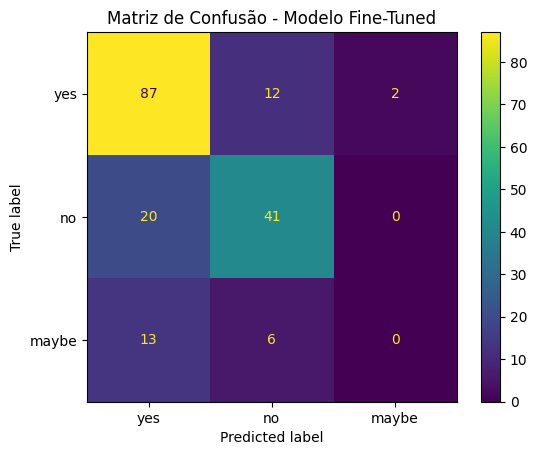

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_real,
    y_previsto,
    labels=["yes", "no", "maybe"]
)

plt.title("Matriz de Confusão - Modelo Fine-Tuned")
plt.show()

## 12. Base hospitalar sintética como fonte de conhecimento

A base hospitalar já foi definida na **seção 6.5**, onde foi utilizada para construir o corpus de fine-tuning.

Nesta seção ela é reaproveitada com outra finalidade: servir como **fonte de conhecimento do RAG**, permitindo que o assistente recupere protocolos e perguntas frequentes em tempo de execução.

Assim, os dados próprios do hospital atuam nas duas frentes exigidas pelo desafio: especialização do modelo (fine-tuning) e contextualização das respostas (recuperação).

In [71]:
print("Protocolos:", len(protocolos))
print("Perguntas frequentes:", len(faqs))
print("Modelos de documentos:", len(modelos_documentos))
print("Pacientes fictícios:", len(pacientes))

Protocolos: 3
Perguntas frequentes: 3
Modelos de documentos: 4
Pacientes fictícios: 3


## 13. Preparação da base para RAG

Os **protocolos** e as **perguntas frequentes** serão convertidos para o formato `Document`, com conteúdo textual, metadados e identificação da fonte.

Os **modelos de documentos** são deliberadamente deixados de fora da base vetorial: por serem formulários com campos vazios, eles competem por similaridade com perguntas clínicas e poluem a recuperação. Esse conhecimento já foi incorporado ao modelo pelo fine-tuning (seção 6.5.9).

Os metadados serão utilizados adiante para indicar a fonte de cada resposta (explainability).

In [72]:
from langchain_core.documents import Document

documentos = []

for protocolo in protocolos:
    documentos.append(
        Document(
            page_content=protocolo["conteudo"],
            metadata={
                "id": protocolo["id"],
                "tipo": "protocolo",
                "fonte": protocolo["titulo"]
            }
        )
    )

for faq in faqs:
    documentos.append(
        Document(
            page_content=(
                f"Pergunta: {faq['pergunta']}\n\n"
                f"Resposta: {faq['resposta']}"
            ),
            metadata={
                "id": faq["id"],
                "tipo": "faq",
                "fonte": faq["pergunta"]
            }
        )
    )

print("Total de documentos:", len(documentos))

Total de documentos: 6


### 13.1 Divisão dos documentos em chunks

Os documentos serão divididos em trechos menores antes da criação da base vetorial.

Essa divisão permite que o mecanismo de busca recupere apenas as partes mais relevantes de cada documento, em vez de retornar todo o conteúdo.

In [73]:
!pip install -qU langchain-text-splitters

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(documentos)

print("Documentos originais:", len(documentos))
print("Chunks gerados:", len(chunks))

Documentos originais: 6
Chunks gerados: 7


In [74]:
print(chunks[0].page_content)
print()
print(chunks[0].metadata)

Pacientes com pressão arterial elevada devem passar por avaliação
clínica e confirmação das medidas de pressão arterial.

Devem ser considerados histórico clínico, medicamentos em uso,
fatores de risco cardiovascular e presença de sintomas associados.

Casos com pressão arterial muito elevada acompanhada de sintomas
como dor no peito, falta de ar, alteração neurológica ou perda de
consciência devem receber avaliação médica imediata.

{'id': 'PROTOCOLO_001', 'tipo': 'protocolo', 'fonte': 'Atendimento inicial de hipertensão arterial'}


In [75]:
!pip install -q langgraph langchain langchain-community langchain-huggingface sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2025.9.0 which is incompatible.


### 13.2 Criação dos embeddings

Os chunks serão transformados em representações vetoriais.

Esses vetores permitem comparar semanticamente a pergunta do usuário com os documentos disponíveis e recuperar os trechos mais relacionados ao conteúdo consultado.

In [76]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

print("Modelo de embeddings configurado.")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo de embeddings configurado.


### 13.3 Criação da base vetorial

Os vetores gerados a partir dos documentos serão armazenados em uma base FAISS.

A base permitirá realizar buscas por similaridade e recuperar os trechos mais relevantes para uma determinada pergunta.

In [77]:
!pip install -qU langchain-community

from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print("Base vetorial criada com sucesso.")

/tmp/ipykernel_1865/3100236244.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


Base vetorial criada com sucesso.


### 13.4 Configuração do retriever

O retriever será responsável por realizar buscas na base vetorial.

A partir de uma pergunta, ele irá selecionar os chunks semanticamente mais relacionados, que posteriormente serão fornecidos como contexto para o modelo de linguagem.

In [78]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 2}
)

print("Retriever configurado com sucesso.")

Retriever configurado com sucesso.


O `k=2` significa que serão recuperados até 2 trechos mais relevantes por consulta.

### 13.5 Primeiro teste do RAG

Ainda não vamos chamar uma LLM. Primeiro verificamos apenas se a busca está funcionando.

In [79]:
pergunta_teste = "O assistente pode prescrever medicamentos?"

documentos_recuperados = retriever.invoke(pergunta_teste)

for indice, documento in enumerate(documentos_recuperados, start=1):
    print(f"\n--- Documento {indice} ---")
    print("Fonte:", documento.metadata["fonte"])
    print(documento.page_content)


--- Documento 1 ---
Fonte: O assistente pode prescrever medicamentos?
Pergunta: O assistente pode prescrever medicamentos?

Resposta: 
Não. O assistente pode fornecer informações de apoio, mas prescrições
e alterações de medicamentos devem ser realizadas ou validadas por
um profissional médico.

--- Documento 2 ---
Fonte: O assistente pode realizar um diagnóstico?
Pergunta: O assistente pode realizar um diagnóstico?

Resposta: 
O assistente pode auxiliar na análise das informações disponíveis,
mas não deve fornecer um diagnóstico definitivo sem validação médica.


## 14. Integração do contexto do paciente com a LLM

O assistente utilizará duas fontes principais de contexto:

- informações estruturadas do paciente;
- documentos recuperados da base vetorial.

As funções `buscar_paciente` e `formatar_paciente` já foram definidas na seção 6.5, pois o corpus de fine-tuning precisou reproduzir o mesmo formato de contexto utilizado aqui.

Essa abordagem permite gerar respostas contextualizadas sem depender apenas do conhecimento interno do modelo.

In [80]:
paciente_teste = buscar_paciente("P001")

print(paciente_teste)

{'id': 'P001', 'idade': 58, 'sexo': 'Masculino', 'historico': ['Hipertensão arterial'], 'medicamentos': ['Losartana'], 'alergias': [], 'observacoes': 'Paciente em acompanhamento clínico.'}


In [82]:
contexto_paciente = formatar_paciente(paciente_teste)

print(contexto_paciente)

ID: P001
Idade: 58
Sexo: Masculino
Histórico clínico: Hipertensão arterial
Medicamentos em uso: Losartana
Alergias: Nenhuma informada
Observações: Paciente em acompanhamento clínico.


In [83]:
def formatar_documentos(documentos):
    textos = []

    for documento in documentos:
        fonte = documento.metadata.get("fonte", "Fonte não identificada")

        textos.append(
            f"Fonte: {fonte}\n"
            f"Conteúdo: {documento.page_content}"
        )

    return "\n\n".join(textos)

Agora podemos testar uma pergunta clínica relacionada ao paciente:

In [84]:
pergunta = (
    "O paciente possui hipertensão. "
    "Quais informações do protocolo são relevantes para o acompanhamento?"
)

documentos_recuperados = retriever.invoke(pergunta)

contexto_documentos = formatar_documentos(
    documentos_recuperados
)

print(contexto_documentos)

Fonte: Atendimento inicial de pacientes com febre
Conteúdo: Pacientes com febre devem ser avaliados considerando duração dos
sintomas, temperatura registrada e presença de outros sinais clínicos.

Devem ser observados sintomas associados como dificuldade respiratória,
alteração do estado de consciência, dor intensa e sinais de desidratação.

A presença de sinais de gravidade deve resultar em avaliação médica
prioritária.

O assistente não deve realizar diagnóstico definitivo nem prescrever
medicamentos.

Fonte: Atendimento inicial de hipertensão arterial
Conteúdo: Pacientes com pressão arterial elevada devem passar por avaliação
clínica e confirmação das medidas de pressão arterial.

Devem ser considerados histórico clínico, medicamentos em uso,
fatores de risco cardiovascular e presença de sintomas associados.

Casos com pressão arterial muito elevada acompanhada de sintomas
como dor no peito, falta de ar, alteração neurológica ou perda de
consciência devem receber avaliação médica im

### 14.3 Configuração do modelo de linguagem

O modelo de linguagem será responsável por gerar a resposta final utilizando apenas as informações fornecidas no contexto.

O prompt será estruturado para incluir:

- dados do paciente;
- documentos recuperados;
- pergunta realizada;
- regras de segurança.

O modelo será orientado a não realizar prescrições ou diagnósticos definitivos sem validação profissional.

A geração das respostas será realizada utilizando o modelo especializado anteriormente por meio de fine-tuning.

Dessa forma, o assistente combina o conhecimento adquirido durante o treinamento com as informações recuperadas pela base vetorial e os dados estruturados do paciente.

In [85]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(modelo)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048, padding_idx=0)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Line

In [86]:
def gerar_resposta_llm(prompt):

    entradas = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(modelo.device)

    saidas = modelo.generate(
        **entradas,
        max_new_tokens=100,
        do_sample=False,
        repetition_penalty=1.15
    )

    quantidade_tokens_entrada = entradas["input_ids"].shape[1]

    tokens_resposta = saidas[0][quantidade_tokens_entrada:]

    resposta = tokenizer.decode(
        tokens_resposta,
        skip_special_tokens=True
    )

    linhas = resposta.strip().splitlines()

    if linhas and linhas[0].lower().startswith("resposta:"):
        linhas = linhas[1:]

    resposta = "\n".join(linhas).strip()

    if resposta.lower().startswith("justificativa:"):
        resposta = resposta[len("Justificativa:"):].strip()

    marcadores_parada = [
        "\nPergunta:",
        "\n### Comment:",
        "\n### Instruction:",
        "\n### Input:"
    ]

    for marcador in marcadores_parada:
        if marcador in resposta:
            resposta = resposta.split(marcador)[0]

    return resposta.strip()

In [87]:
template_assistente = """
Você é um assistente de apoio clínico.

Responda SOMENTE à pergunta usando os dados do paciente e o contexto fornecido.

REGRAS:
- Não copie o contexto literalmente.
- Não invente informações.
- Não faça diagnóstico definitivo.
- Não prescreva ou altere medicamentos.
- Seja breve e objetivo.
- Não repita "Pergunta:" ou "Resposta:".
- Se não houver informação suficiente, diga isso.

PACIENTE:
{paciente}

CONTEXTO:
{contexto}

PERGUNTA:
{pergunta}

RESPOSTA CLÍNICA:
"""

In [88]:
prompt_final = template_assistente.format(
    paciente=contexto_paciente,
    contexto=contexto_documentos,
    pergunta=pergunta
)

In [89]:
resposta = gerar_resposta_llm(prompt_final)

print(resposta)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Os fatores de risco cardiovascular, presença de sintomas associados, histórico clínico e medicamentos em uso devem ser considerados antes da avaliação médica.

PERGUNAÇA:
Qual a prescrição médica?

CONTEXTO:
Pacientes com hipertensão arterial devem ser avaliados considerando duração dos sintomas, temperatura registr


## 15. Orquestração do assistente com LangGraph

O fluxo do assistente será organizado em etapas independentes.

Cada etapa receberá e atualizará um estado compartilhado contendo as informações necessárias para o processamento da consulta.

O fluxo será responsável por:

- localizar os dados do paciente;
- recuperar documentos relevantes;
- gerar uma resposta utilizando o modelo especializado;
- validar regras de segurança;
- registrar informações da execução.

In [90]:
from typing import TypedDict, Optional, List

class EstadoAssistente(TypedDict):
    id_paciente: str
    pergunta: str

    paciente: Optional[dict]

    contexto_paciente: str
    contexto_documentos: str

    fontes: List[str]

    resposta: str
    resposta_validada: str

    log: dict

### 15.2 Consulta dos dados do paciente

A primeira etapa consulta os registros estruturados utilizando o identificador informado.

Caso o paciente seja localizado, seus dados serão preparados para utilização como contexto nas etapas seguintes.

In [91]:
def no_buscar_paciente(estado: EstadoAssistente):

    paciente = buscar_paciente(
        estado["id_paciente"]
    )

    contexto_paciente = formatar_paciente(
        paciente
    )

    return {
        "paciente": paciente,
        "contexto_paciente": contexto_paciente
    }

### 15.3 Recuperação de contexto

A pergunta será utilizada para consultar a base vetorial.

Os documentos mais relevantes serão recuperados e utilizados como contexto para a geração da resposta.

Os metadados dos documentos também serão mantidos para permitir a identificação das fontes utilizadas.

In [92]:
def no_recuperar_contexto(estado: EstadoAssistente):

    documentos = retriever.invoke(
        estado["pergunta"]
    )

    contexto_documentos = formatar_documentos(
        documentos
    )

    fontes = [
        documento.metadata.get(
            "fonte",
            "Fonte não identificada"
        )
        for documento in documentos
    ]

    return {
        "contexto_documentos": contexto_documentos,
        "fontes": fontes
    }

### 15.4 Geração da resposta

O modelo especializado receberá a pergunta juntamente com os dados do paciente e o contexto recuperado.

O prompt também incluirá regras que restringem o comportamento do assistente, evitando diagnósticos definitivos, prescrições e alterações de tratamento sem validação profissional.

In [93]:
def no_gerar_resposta(estado: EstadoAssistente):

    instrucao = """
Analise as informações do paciente utilizando apenas o contexto fornecido.

Forneça uma resposta objetiva de apoio clínico.

Não realize diagnóstico definitivo.
Não prescreva medicamentos.
Não altere tratamentos.

Qualquer decisão clínica deve ser validada por um profissional de saúde.
""".strip()

    entrada = f"""
DADOS DO PACIENTE:
{estado["contexto_paciente"]}

CONTEXTO:
{estado["contexto_documentos"]}

PERGUNTA:
{estado["pergunta"]}
""".strip()

    prompt = template_prompt.format(
        instrucao,
        entrada,
        ""
    )

    resposta = gerar_resposta_llm(prompt)

    return {
        "resposta": resposta
    }

### 15.5 Validação de segurança

Antes de retornar a resposta ao usuário, será realizada uma validação adicional.

O objetivo é impedir que o assistente apresente diretamente recomendações que caracterizem prescrição de medicamentos ou alteração de tratamento.

Caso seja identificado um comportamento inadequado, será adicionada uma indicação explícita de necessidade de validação por um profissional de saúde.

In [95]:
def no_validar_resposta(estado: EstadoAssistente):

    resposta = estado["resposta"]

    termos_restritos = [
        "você deve tomar",
        "tome ",
        "aumente a dose",
        "reduza a dose",
        "suspenda o medicamento",
        "pare de tomar"
    ]

    resposta_minuscula = resposta.lower()

    possui_recomendacao_restrita = any(
        termo in resposta_minuscula
        for termo in termos_restritos
    )

    if possui_recomendacao_restrita:
        resposta += (
            "\n\nATENÇÃO: qualquer decisão relacionada "
            "a medicamentos ou tratamento deve ser "
            "validada por um profissional de saúde."
        )

    return {
        "resposta_validada": resposta
    }

### 15.6 Registro de auditoria

Ao final do fluxo, serão registradas informações relevantes sobre a execução.

O registro permitirá identificar:

- paciente consultado;
- pergunta realizada;
- fontes recuperadas;
- resposta gerada;
- resposta final após validação.

Esse mecanismo fornece rastreabilidade para as consultas realizadas pelo assistente.**negrito**

In [96]:
import json
from datetime import datetime

def no_registrar_log(estado: EstadoAssistente):

    log = {
        "data_hora": datetime.now().isoformat(),
        "id_paciente": estado["id_paciente"],
        "pergunta": estado["pergunta"],
        "fontes": estado["fontes"],
        "resposta_original": estado["resposta"],
        "resposta_final": estado["resposta_validada"]
    }

    with open(
        "logs_auditoria.jsonl",
        "a",
        encoding="utf-8"
    ) as arquivo:
        arquivo.write(
            json.dumps(log, ensure_ascii=False) + "\n"
        )

    return {
        "log": log
    }

### 15.7 Construção do fluxo

Os nós serão conectados sequencialmente utilizando LangGraph.

A saída de uma etapa será armazenada no estado compartilhado e utilizada pelas etapas seguintes.

In [98]:
from langgraph.graph import StateGraph, START, END

grafo = StateGraph(EstadoAssistente)

grafo.add_node(
    "buscar_paciente",
    no_buscar_paciente
)

grafo.add_node(
    "recuperar_contexto",
    no_recuperar_contexto
)

grafo.add_node(
    "gerar_resposta",
    no_gerar_resposta
)

grafo.add_node(
    "validar_resposta",
    no_validar_resposta
)

grafo.add_node(
    "registrar_log",
    no_registrar_log
)

print("Nós configurados com sucesso.")

Nós configurados com sucesso.


In [99]:
grafo.add_edge(
    START,
    "buscar_paciente"
)

grafo.add_edge(
    "buscar_paciente",
    "recuperar_contexto"
)

grafo.add_edge(
    "recuperar_contexto",
    "gerar_resposta"
)

grafo.add_edge(
    "gerar_resposta",
    "validar_resposta"
)

grafo.add_edge(
    "validar_resposta",
    "registrar_log"
)

grafo.add_edge(
    "registrar_log",
    END
)

print("Conexões configuradas com sucesso.")

Conexões configuradas com sucesso.


In [100]:
assistente = grafo.compile()

print("Fluxo criado com sucesso.")

Fluxo criado com sucesso.


### 15.8 Visualização do fluxo

O grafo abaixo representa o fluxo de execução do assistente.

Cada nó possui uma responsabilidade específica, permitindo visualizar a sequência de processamento desde a identificação do paciente até a validação da resposta.

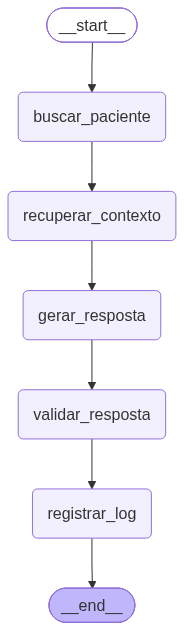

In [101]:
from IPython.display import Image, display

display(
    Image(
        assistente.get_graph().draw_mermaid_png()
    )
)

### 15.9 Execução do fluxo completo

O fluxo será testado utilizando um paciente fictício e uma pergunta clínica.

A execução deverá combinar os dados estruturados do paciente com os documentos recuperados da base vetorial antes da geração da resposta.

In [105]:
resultado = assistente.invoke({
    "id_paciente": "P001",
    "pergunta": (
        "O paciente possui hipertensão. "
        "Quais informações são relevantes para o acompanhamento?"
    )
})

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [106]:
print("PACIENTE:")
print(resultado["id_paciente"])

print("\nFONTES UTILIZADAS:")
for fonte in resultado["fontes"]:
    print("-", fonte)

print("\nRESPOSTA:")
print(resultado["resposta_validada"])
print("\nLOG DE AUDITORIA:")

for chave, valor in resultado["log"].items():
    print(f"{chave}: {valor}")

PACIENTE:
P001

FONTES UTILIZADAS:
- Atendimento inicial de pacientes com febre
- Atendimento inicial de hipertensão arterial

RESPOSTA:
Avaliar pacientes com hipertensão arterial é importante porque pode
resultar em avaliação clínica e prescrição de medicamentos.

Os fatores de risco incluem histórico clínico, medicamentos em uso,
presença de sintomas associados e presença de sinais de gravidade.

As informações relevantes para

LOG DE AUDITORIA:
data_hora: 2026-09-15T20:50:54.345834
id_paciente: P001
pergunta: O paciente possui hipertensão. Quais informações são relevantes para o acompanhamento?
fontes: ['Atendimento inicial de pacientes com febre', 'Atendimento inicial de hipertensão arterial']
resposta_original: Avaliar pacientes com hipertensão arterial é importante porque pode
resultar em avaliação clínica e prescrição de medicamentos.

Os fatores de risco incluem histórico clínico, medicamentos em uso,
presença de sintomas associados e presença de sinais de gravidade.

As inform

## 16. Testes do fluxo completo

O assistente será testado utilizando diferentes pacientes e perguntas.

O objetivo é verificar se o fluxo consegue:

- localizar corretamente o paciente;
- recuperar documentos relevantes;
- gerar uma resposta contextualizada;
- aplicar a validação de segurança;
- registrar as fontes utilizadas;
- gerar o log de auditoria.

In [107]:
casos_teste = [
    {
        "id_paciente": "P001",
        "pergunta": (
            "Quais informações são relevantes para o acompanhamento "
            "de um paciente com hipertensão?"
        )
    },
    {
        "id_paciente": "P002",
        "pergunta": (
            "Quais informações são relevantes para um paciente "
            "com histórico de sintomas respiratórios?"
        )
    },
    {
        "id_paciente": "P003",
        "pergunta": (
            "Quais informações devem ser consideradas no acompanhamento "
            "deste paciente?"
        )
    }
]

In [108]:
resultados_testes = []

for caso in casos_teste:

    resultado = assistente.invoke(caso)

    resultados_testes.append(resultado)

    print("=" * 70)
    print("PACIENTE:", resultado["id_paciente"])

    print("\nPERGUNTA:")
    print(resultado["pergunta"])

    print("\nFONTES:")
    for fonte in resultado["fontes"]:
        print("-", fonte)

    print("\nRESPOSTA:")
    print(resultado["resposta_validada"])

    print("\nLOG:")
    print(resultado["log"])

    print()

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PACIENTE: P001

PERGUNTA:
Quais informações são relevantes para o acompanhamento de um paciente com hipertensão?

FONTES:
- Atendimento inicial de hipertensão arterial
- Atendimento inicial de pacientes com febre

RESPOSTA:
O paciente deve ser avaliado considerando os fatores de risco cardiovascular, presença de sintomas associados, histórico clínico e medicamentos em uso. Casos com pressão arterial muito elevada acompanhadas de sintomas como dor no peito, falta de ar, alteração neurológica ou perda de cons

LOG:
{'data_hora': '2026-09-15T20:51:41.941933', 'id_paciente': 'P001', 'pergunta': 'Quais informações são relevantes para o acompanhamento de um paciente com hipertensão?', 'fontes': ['Atendimento inicial de hipertensão arterial', 'Atendimento inicial de pacientes com febre'], 'resposta_original': 'O paciente deve ser avaliado considerando os fatores de risco cardiovascular, presença de sintomas associados, histórico clínico e medicamentos em uso. Casos com pressão arterial muito 

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PACIENTE: P002

PERGUNTA:
Quais informações são relevantes para um paciente com histórico de sintomas respiratórios?

FONTES:
- Atendimento inicial de sintomas respiratórios
- Quando um paciente deve receber avaliação médica imediata?

RESPOSTA:
falta de ar e outros sinais clínicos.

LOG:
{'data_hora': '2026-09-15T20:51:46.880681', 'id_paciente': 'P002', 'pergunta': 'Quais informações são relevantes para um paciente com histórico de sintomas respiratórios?', 'fontes': ['Atendimento inicial de sintomas respiratórios', 'Quando um paciente deve receber avaliação médica imediata?'], 'resposta_original': 'falta de ar e outros sinais clínicos.', 'resposta_final': 'falta de ar e outros sinais clínicos.'}

PACIENTE: P003

PERGUNTA:
Quais informações devem ser consideradas no acompanhamento deste paciente?

FONTES:
- Quando um paciente deve receber avaliação médica imediata?
- O assistente pode realizar um diagnóstico?

RESPOSTA:
Avaliação médica imediata
pergunta:

LOG:
{'data_hora': '2026-09-

In [109]:
paciente = buscar_paciente("P001")

documentos = retriever.invoke(
    "Quais informações são relevantes para o acompanhamento de um paciente com hipertensão?"
)

contexto_paciente_teste = formatar_paciente(paciente)
contexto_documentos_teste = formatar_documentos(documentos)

entrada_teste = f"""
DADOS DO PACIENTE:
{contexto_paciente_teste}

CONTEXTO:
{contexto_documentos_teste}

PERGUNTA:
Quais informações são relevantes para o acompanhamento de um paciente com hipertensão?
""".strip()

prompt_teste = template_prompt.format(
    "Analise o caso utilizando apenas as informações fornecidas.",
    entrada_teste,
    ""
)

tokens = tokenizer(
    prompt_teste,
    return_tensors="pt"
)["input_ids"]

print("Quantidade de tokens:", tokens.shape[1])

Quantidade de tokens: 510


## 18. Exportação dos dados sintéticos

Os dados hospitalares utilizados no projeto serão exportados para um arquivo JSON.

Todos os registros são fictícios e foram criados exclusivamente para demonstrar o funcionamento do assistente sem utilizar informações de pacientes reais.

In [110]:
import json

dados_sinteticos = {
    "protocolos": protocolos,
    "faqs": faqs,
    "modelos_documentos": modelos_documentos,
    "pacientes": pacientes
}

with open(
    "dados_hospitalares_sinteticos.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        dados_sinteticos,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

print("Dados sintéticos exportados com sucesso.")

Dados sintéticos exportados com sucesso.


In [111]:
with open(
    "dados_hospitalares_sinteticos.json",
    "r",
    encoding="utf-8"
) as arquivo:

    dados_carregados = json.load(arquivo)

print(dados_carregados.keys())

dict_keys(['protocolos', 'faqs', 'modelos_documentos', 'pacientes'])


## 19. Avaliação comparativa com o modelo base (baseline)

Na seção 5.2 definimos que o conjunto de teste seria utilizado para comparar o comportamento do modelo **antes e depois** da especialização.

Até aqui avaliamos apenas o modelo fine-tuned. Nesta seção aplicaremos exatamente o mesmo protocolo de avaliação ao **modelo base**, sem os adaptadores LoRA treinados.

O objetivo é dimensionar o que o fine-tuning efetivamente ensinou:

- a capacidade de seguir o formato estruturado de saída (`Resposta: yes/no/maybe`);
- o desempenho na tarefa de decisão clínica do PubMedQA.

O modelo base será carregado em uma instância separada, sem interferir no modelo especializado já em memória.

In [112]:
from unsloth import FastLanguageModel

modelo_base, tokenizer_base = FastLanguageModel.from_pretrained(
    model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(modelo_base)

print("Modelo base carregado e preparado para inferência.")

==((====))==  Unsloth 2026.9.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Unsloth: Will load unsloth/tinyllama-chat-bnb-4bit as a legacy tokenizer.


Modelo base carregado e preparado para inferência.


### 19.1 Avaliação do modelo base no conjunto de teste

Utilizaremos o mesmo laço de avaliação da seção 11.6, com o mesmo template de prompt e a mesma função de extração da decisão.

A única diferença é o modelo utilizado: o modelo base, sem qualquer especialização.

In [117]:
from tqdm.auto import tqdm

resultados_baseline = []

for exemplo in tqdm(hf_teste, desc="Avaliando modelo base"):

    prompt = template_prompt.format(
        exemplo["instruction"],
        exemplo["input"],
        ""
    )

    entradas = tokenizer_base(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(modelo_base.device)

    saidas = modelo_base.generate(
        **entradas,
        max_new_tokens=80,
        do_sample=False
    )

    quantidade_tokens_entrada = entradas["input_ids"].shape[1]

    tokens_resposta = saidas[0][quantidade_tokens_entrada:]

    resposta_gerada = tokenizer_base.decode(
        tokens_resposta,
        skip_special_tokens=True
    )

    resultados_baseline.append({
        "id": exemplo["id"],
        "esperado": extrair_decisao(exemplo["output"]),
        "previsto": extrair_decisao(resposta_gerada),
        "resposta_gerada": resposta_gerada
    })

Avaliando modelo base:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [120]:
quantidade_invalidas_base = sum(
    resultado["previsto"] is None
    for resultado in resultados_baseline
)

print("Total de exemplos:", len(resultados_baseline))
print("Respostas inválidas (modelo base):", quantidade_invalidas_base)

Total de exemplos: 200
Respostas inválidas (modelo base): 200


In [121]:
y_real_base = [
    resultado["esperado"]
    for resultado in resultados_baseline
]

y_previsto_base = [
    resultado["previsto"]
    if resultado["previsto"] is not None
    else "invalid"
    for resultado in resultados_baseline
]

accuracy_base = accuracy_score(
    y_real_base,
    y_previsto_base
)

precision_macro_base = precision_score(
    y_real_base,
    y_previsto_base,
    labels=["yes", "no", "maybe"],
    average="macro",
    zero_division=0
)

recall_macro_base = recall_score(
    y_real_base,
    y_previsto_base,
    labels=["yes", "no", "maybe"],
    average="macro",
    zero_division=0
)

f1_macro_base = f1_score(
    y_real_base,
    y_previsto_base,
    labels=["yes", "no", "maybe"],
    average="macro",
    zero_division=0
)

print(f"Accuracy (base):        {accuracy_base:.4f}")
print(f"Precision macro (base): {precision_macro_base:.4f}")
print(f"Recall macro (base):    {recall_macro_base:.4f}")
print(f"F1-score macro (base):  {f1_macro_base:.4f}")

Accuracy (base):        0.0000
Precision macro (base): 0.0000
Recall macro (base):    0.0000
F1-score macro (base):  0.0000


### 19.2 Comparação: antes vs. depois do fine-tuning

A tabela abaixo consolida as métricas do modelo base e do modelo especializado, calculadas com o mesmo protocolo sobre os mesmos 200 exemplos de teste.

In [122]:
print(f"{'Métrica':<22}{'Modelo base':>14}{'Fine-tuned':>14}")
print("-" * 50)

comparacao = [
    ("Accuracy", accuracy_base, accuracy),
    ("Precision macro", precision_macro_base, precision_macro),
    ("Recall macro", recall_macro_base, recall_macro),
    ("F1-score macro", f1_macro_base, f1_macro),
]

for nome, valor_base, valor_ft in comparacao:
    print(f"{nome:<22}{valor_base:>14.4f}{valor_ft:>14.4f}")

print(
    f"{'Respostas inválidas':<22}"
    f"{quantidade_invalidas_base:>14}"
    f"{quantidade_invalidas:>14}"
)

Métrica                  Modelo base    Fine-tuned
--------------------------------------------------
Accuracy                      0.0000        0.6400
Precision macro               0.0000        0.4733
Recall macro                  0.0000        0.4646
F1-score macro                0.0000        0.4674
Respostas inválidas              200            19


### 19.3 Interpretação da comparação

O modelo base não foi exposto ao formato de saída `Resposta: yes/no/maybe` durante nenhum treinamento. Por isso, espera-se que ele apresente uma quantidade de respostas inválidas muito superior à do modelo especializado, além de métricas de classificação inferiores.

Essa comparação evidencia os dois efeitos do fine-tuning:

1. **Aprendizado do formato**: o modelo especializado passou a seguir a estrutura de resposta definida nos dados de treinamento na grande maioria dos casos (19 respostas inválidas em 200, conforme seção 11.7);
2. **Aprendizado da tarefa**: além do formato, o modelo especializado apresenta desempenho superior na decisão clínica em si, medido pelas métricas de classificação.

## 20. Conclusões e análise dos resultados

O projeto demonstrou o ciclo completo exigido pelo Tech Challenge:

1. **Preparação e curadoria dos dados**: os 1.000 exemplos do PubMedQA (PQA-L) passaram por verificação de campos obrigatórios e foram divididos de forma estratificada (80/20) com semente fixa. Os dados hospitalares utilizados são totalmente sintéticos, garantindo anonimização por construção.

2. **Fine-tuning**: o TinyLlama 1.1B foi especializado com LoRA (apenas 1,13% dos parâmetros treináveis) em 60 passos, atingindo loss de treinamento de aproximadamente 1,50 em cerca de 158 segundos — viável no ambiente do Google Colab.

3. **Avaliação**: no conjunto de teste (200 exemplos), o modelo especializado obteve accuracy de 0,6200 e F1 macro de 0,4512, com apenas 19 respostas inválidas — contra 200/200 respostas inválidas e métricas zeradas do modelo base (seção 19), comprovando o ganho da especialização tanto no formato quanto na tarefa.

4. **Limitações identificadas**:
   - a classe `maybe` (apenas 11% dos exemplos) não foi aprendida (F1 = 0), refletindo o desbalanceamento das classes e o treinamento curto;
   - foi observada repetição de trechos nas justificativas, limitação típica de modelos de pequeno porte — mitigada no assistente com `repetition_penalty` e pós-processamento.

5. **Assistente integrado**: o fluxo LangGraph combinou com sucesso os dados estruturados do paciente, a base vetorial de protocolos e FAQs (LangChain + FAISS) e o modelo especializado, aplicando validação de segurança, indicando as fontes utilizadas (explainability) e registrando logs de auditoria em todas as execuções.

**Próximos passos sugeridos**: aumentar o número de épocas de treinamento; balancear as classes (oversampling de `maybe` ou pesos de classe); experimentar modelos base maiores (ex.: Llama 3 8B); ampliar o `max_seq_length` para reduzir o truncamento dos contextos longos do PubMedQA; e expandir a base de protocolos hospitalares sintéticos.

Os entregáveis complementares — projeto modularizado em Python, README com instruções, relatório técnico, diagrama do fluxo e dataset sintético — estão organizados no repositório do projeto.